# Download Data

In [ ]:
# Fetch data
!mkdir data
!wget -P data/ https://s3.amazonaws.com/video.udacity-data.com/topher/2018/May/5aea1b91_train-test-data/train-test-data.zip
!unzip -n data/train-test-data.zip -d data

mkdir: data: File exists
zsh:1: command not found: wget
unzip:  cannot find or open data/train-test-data.zip, data/train-test-data.zip.zip or data/train-test-data.zip.ZIP.


In [1]:
device = 'mps'

# Setup Environment

In [2]:
import copy

In [4]:
# No need if you are using colab

# !pip install matplotlib~=3.5.2
# !pip install scikit-image==0.19.2
# !pip install torch~=1.8.1
# !pip install torchvision~=0.9.1
# !pip install numpy~=1.21.6
# !pip install pillow~=9.1.1
# !pip install tqdm~=4.64.0
# !pip install jupyter==1.0.0
# !pip install opencv-python==4.6.0.66
# !pip install pandas==1.3.5


# Visualize the data

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

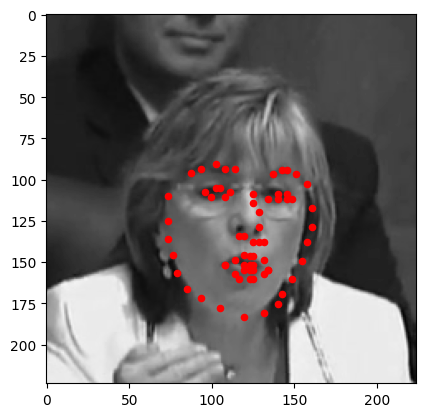

In [65]:
# importing the required libraries
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, utils
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torch.optim import lr_scheduler
import torch.optim as optim
from tqdm import tqdm


# the transforms we defined in Notebook 1 are in the helper file `custom_transforms.py`
from custom_transforms import (
    Rescale,
    RandomCrop,
    NormalizeOriginal,
    ToTensor,
)

# the dataset we created in Notebook 1
from facial_keypoints_dataset import FacialKeypointsDataset



# defining the data_transform using transforms.Compose([all tx's, . , .])
# order matters! i.e. rescaling should come before a smaller crop
data_transform = transforms.Compose(
    [Rescale(250), RandomCrop(224), NormalizeOriginal(), ToTensor()]
)

training_keypoints_csv_path = os.path.join("data", "training_frames_keypoints.csv")
training_data_dir = os.path.join("data", "training")
test_keypoints_csv_path = os.path.join("data", "test_frames_keypoints.csv")
test_data_dir = os.path.join("data", "test")


# create the transformed dataset
transformed_dataset = FacialKeypointsDataset(
    csv_file=training_keypoints_csv_path,
    root_dir=training_data_dir,
    transform=data_transform,
)
# load training data in batches
batch_size = 16
train_loader = DataLoader(
    transformed_dataset, batch_size=batch_size, shuffle=True, num_workers=4
)

# creating the test dataset
test_dataset = FacialKeypointsDataset(
    csv_file=test_keypoints_csv_path, 
    root_dir=test_data_dir, 
    transform=data_transform
)
# loading test data in batches
batch_size = 16
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True, num_workers=4
)

for i, data in enumerate(test_loader):
    sample = data
    image = sample['image'][0]
    keypoints = sample['keypoints'][0]
    # plot the image black and white
    plt.imshow(image.numpy().transpose(1, 2, 0), cmap='gray')
    plt.scatter(keypoints[:, 0]*50+100, keypoints[:, 1]*50+100, c='r', s=20)
    plt.show()
    break


# Train your model

In [5]:
from models import SimpleNet, Resnet18Grayscale, Dinov2_grayscale

# Defining the loss and optimization
# criterion = nn.SmoothL1Loss()
criterion = nn.MSELoss()

net = SimpleNet()
# net = Resnet18Grayscale()
# net = Dinov2_grayscale()
losses = []

print(net)

optimizer = optim.Adam(net.parameters(), lr=0.001)

def train_net(n_epochs):
    losses = []
    # prepare the net for training
    net.train()
    net.to(device)

    # loop over the dataset multiple times
    for epoch in tqdm(range(n_epochs), desc="training"):

        running_loss = 0.0

        # train on batches of data, assumes we already have train_loader
        batch_i = 0
        for data in tqdm(train_loader, desc="epoch {}".format(epoch)):

            # get the input images and their corresponding labels
            images = data["image"].float()
            key_pts = data["keypoints"].float()

            # training code here
            flattened_key_pts = key_pts.view(key_pts.size(0), -1)
            optimizer.zero_grad()
            predicted_key_pts = net(images.to(device))
            loss = criterion(predicted_key_pts, flattened_key_pts.to(device))
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
            
            # print loss statistics
            running_loss += loss.item()

            batch_i += 1

    return losses
    print("Finished Training")

# train the network
n_epochs = 10  # we start at small values, then we increase when we fixed the model structure and hyperparams

# losses = train_net(n_epochs)

SimpleNet(
  (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.1, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.2, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(4, 4), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p=0.3, inplace=False)
  (conv4): Conv2d(128, 256, kernel_size=(4, 4), stride=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

## Hyperparameters Changes

In [16]:
net = SimpleNet()
losses1 = train_net(n_epochs)
net_lr001_conv4x4_mse = copy.deepcopy(net) # epochs 10, lr 0.001, conv filter 4x4

training:   0%|          | 0/10 [00:00<?, ?it/s]RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for

In [17]:
net = SimpleNet(filter_size=4)
optimizer = optim.Adam(net.parameters(), lr=0.0001)
losses2 = train_net(n_epochs)
net_lr0001_conv4x4_mse = copy.deepcopy(net) # epochs 10, lr 0.0001, conv filter 4x4

training:   0%|          | 0/10 [00:00<?, ?it/s]RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for

In [18]:
net = SimpleNet(filter_size=5)
optimizer = optim.Adam(net.parameters(), lr=0.0001)
losses3 = train_net(n_epochs)
net_lr0001_conv5x5_mse = copy.deepcopy(net) # epochs 10, lr 0.0001, conv filter 5x5

training:   0%|          | 0/10 [00:00<?, ?it/s]RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for

In [19]:
criterion = nn.SmoothL1Loss()
net = SimpleNet(filter_size=5)
optimizer = optim.Adam(net.parameters(), lr=0.0001)
losses4 = train_net(n_epochs)
net_lr0001_conv5x5_smoothl1 = copy.deepcopy(net) # epochs 10, lr 0.0001, conv filter 5x5, smooth l1 loss instead of mse

training:   0%|          | 0/10 [00:00<?, ?it/s]RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for

## Save / Load the models

In [13]:
# save loss curves 
def save_loss(losses, filename):
    plt.plot(losses)
    plt.title("Loss vs. Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.savefig(filename)
    plt.close()

In [ ]:
save_loss(losses1, "losses1.png")
save_loss(losses2, "losses2.png")
save_loss(losses3, "losses3.png")
save_loss(losses4, "losses4.png")

In [ ]:
# save the models 
torch.save(net_lr001_conv4x4_mse.state_dict(), 'model1.pth')
torch.save(net_lr0001_conv4x4_mse.state_dict(), 'model2.pth')
torch.save(net_lr0001_conv5x5_mse.state_dict(), 'model3.pth')
torch.save(net_lr0001_conv5x5_smoothl1.state_dict(), 'model4.pth')

In [6]:
from models import SimpleNet, Resnet18Grayscale, Dinov2_grayscale

In [7]:
# load the models
net_lr001_conv4x4_mse, net_lr0001_conv4x4_mse, net_lr0001_conv5x5_mse, net_lr0001_conv5x5_smoothl1 = SimpleNet(), SimpleNet(), SimpleNet(filter_size=5), SimpleNet(filter_size=5)
net_lr001_conv4x4_mse.load_state_dict(torch.load('models/model1.pth'))
net_lr0001_conv4x4_mse.load_state_dict(torch.load('models/model2.pth'))
net_lr0001_conv5x5_mse.load_state_dict(torch.load('models/model3.pth'))
net_lr0001_conv5x5_smoothl1.load_state_dict(torch.load('models/model4.pth'))

<All keys matched successfully>

## With Best Hyperparameters

In [21]:
n_epochs = 30 
criterion = nn.SmoothL1Loss()
net = SimpleNet(filter_size=5)
optimizer = optim.Adam(net.parameters(), lr=0.0001)
losses_best = train_net(n_epochs)
net_best_hyperparams = copy.deepcopy(net) # epochs 30, lr 0.0001, conv filter 5x5, smooth l1 loss instead of mse

training:   0%|          | 0/30 [00:00<?, ?it/s]RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for

In [22]:
# save loss curves
save_loss(losses_best, "losses_best.png")

In [ ]:
# save the model
torch.save(net_best_hyperparams.state_dict(), 'model5.pth')


In [8]:
# load the model
net_best_hyperparams = SimpleNet(filter_size=5)
net_best_hyperparams.load_state_dict(torch.load('model5.pth'))
net = net_best_hyperparams

## ResNet 


In [12]:
# Implement a training strategy where you initially freeze the pretrained
# backbone and only train the new layers, then fine-tune the entire model
def train_resnet(n_epochs):
    losses = []
    # prepare the net for training
    net.train()
    net.to(device)
    # freeze 
    # Only train the new FC layer
    for param in net.resnet18.parameters():
        param.requires_grad = False
    for param in net.resnet18.fc.parameters():
        param.requires_grad = True

    # Phase 1
    optimizer_phase1 = torch.optim.Adam(filter(lambda p: p.requires_grad, net.parameters()), lr=0.001)
    for epoch in tqdm(range(n_epochs), desc="training"):
        running_loss = 0.0
        # train on batches of data, assumes we already have train_loader
        batch_i = 0
        for data in tqdm(train_loader, desc="epoch {}".format(epoch)):

            # get the input images and their corresponding labels
            images = data["image"].float()
            key_pts = data["keypoints"].float()

            # training code here
            flattened_key_pts = key_pts.view(key_pts.size(0), -1)
            optimizer_phase1.zero_grad()
            predicted_key_pts = net(images.to(device))
            loss = criterion(predicted_key_pts, flattened_key_pts.to(device))
            loss.backward()
            optimizer_phase1.step()
            losses.append(loss.item())
            
            # loss statistics
            running_loss += loss.item()
            batch_i += 1
    
    # Phase 2: Fine-tuning the entire model
    for param in net.parameters():
        param.requires_grad = True
    optimizer_phase2 = torch.optim.Adam(net.parameters(), lr=0.0001) # lower learning rate because we are fine-tuning
    for epoch in tqdm(range(n_epochs), desc="training"):
        running_loss = 0.0
        # train on batches of data, assumes we already have train_loader
        batch_i = 0
        for data in tqdm(train_loader, desc="epoch {}".format(epoch)):

            # get the input images and their corresponding labels
            images = data["image"].float()
            key_pts = data["keypoints"].float()

            # training code here
            flattened_key_pts = key_pts.view(key_pts.size(0), -1)
            optimizer_phase2.zero_grad()
            predicted_key_pts = net(images.to(device))
            loss = criterion(predicted_key_pts, flattened_key_pts.to(device))
            loss.backward()
            optimizer_phase2.step()
            losses.append(loss.item())
            
            # loss statistics
            running_loss += loss.item()
            batch_i += 1
    return losses
    print("Finished Training")

In [13]:
criterion = nn.SmoothL1Loss()
net = Resnet18Grayscale()
resnet_losses = train_resnet(n_epochs)
resnet_lr0001_smoothl1 = copy.deepcopy(net) # epochs 10, lr 0.0001

/Users/brayton/opt/anaconda3/envs/my_tf_env/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/brayton/opt/anaconda3/envs/my_tf_env/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
training:   0%|          | 0/10 [00:00<?, ?it/s]RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importe

In [15]:
save_loss(resnet_losses, "resnet_losses.png")

In [ ]:
# save the model
torch.save(resnet_lr0001_smoothl1.state_dict(), 'model_resnet.pth')

In [8]:
# load the model
resnet_lr0001_smoothl1 = Resnet18Grayscale()
resnet_lr0001_smoothl1.load_state_dict(torch.load('models/model_resnet_new.pth'))

/Users/brayton/opt/anaconda3/envs/my_tf_env/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/brayton/opt/anaconda3/envs/my_tf_env/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

## DINO

In [29]:
# train_dino = train_resnet # same strategy as resnet
# train_dino = train_net
# Implement a training strategy where you initially freeze the pretrained
# backbone and only train the new layers, then fine-tune the entire model
def train_dino(n_epochs):
    losses = []
    # prepare the net for training
    net.train()
    net.to(device)
    # freeze 
    # Only train the regession head
    for param in net.dino2.parameters():
        param.requires_grad = False

    # Phase 1
    optimizer_phase1 = torch.optim.Adam(filter(lambda p: p.requires_grad, net.parameters()), lr=0.001)
    for epoch in tqdm(range(n_epochs), desc="training"):
        running_loss = 0.0
        # train on batches of data, assumes we already have train_loader
        batch_i = 0
        for data in tqdm(train_loader, desc="epoch {}".format(epoch)):

            # get the input images and their corresponding labels
            images = data["image"].float()
            key_pts = data["keypoints"].float()

            # training code here
            flattened_key_pts = key_pts.view(key_pts.size(0), -1)
            optimizer_phase1.zero_grad()
            predicted_key_pts = net(images.to(device))
            loss = criterion(predicted_key_pts, flattened_key_pts.to(device))
            loss.backward()
            optimizer_phase1.step()
            losses.append(loss.item())
            
            # loss statistics
            running_loss += loss.item()
            batch_i += 1
    
    # Phase 2: Fine-tuning the entire model
    for param in net.parameters():
        param.requires_grad = True
    # optimizer_phase2 = torch.optim.Adam(net.parameters(), lr=0.0001) # lower learning rate because we are fine-tuning
    optimizer_phase2 = torch.optim.Adam([
        {'params': net.dino2.parameters(), 'lr': 0.000001},  # Much lower LR for backbone
        {'params': net.regession_head.parameters(), 'lr': 0.00005}        # Slightly lower LR for head
    ])
    for epoch in tqdm(range(n_epochs), desc="training"):
        running_loss = 0.0
        # train on batches of data, assumes we already have train_loader
        batch_i = 0
        for data in tqdm(train_loader, desc="epoch {}".format(epoch)):

            # get the input images and their corresponding labels
            images = data["image"].float()
            key_pts = data["keypoints"].float()

            # training code here
            flattened_key_pts = key_pts.view(key_pts.size(0), -1)
            optimizer_phase2.zero_grad()
            predicted_key_pts = net(images.to(device))
            loss = criterion(predicted_key_pts, flattened_key_pts.to(device))
            loss.backward()
            optimizer_phase2.step()
            losses.append(loss.item())
            
            # loss statistics
            running_loss += loss.item()
            batch_i += 1
    return losses
    print("Finished Training")

In [36]:
n_epochs = 30 

In [37]:
criterion = nn.SmoothL1Loss()
net = Dinov2_grayscale()
dino_losses = train_dino(n_epochs)
dino_lr0001_smoothl1 = copy.deepcopy(net) # epochs 10, lr 0.0001

Using cache found in /Users/brayton/.cache/torch/hub/facebookresearch_dinov2_main
training:   0%|          | 0/30 [00:00<?, ?it/s]RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https:/

In [38]:
save_loss(dino_losses, "dino_losses.png")

In [39]:
# save the model
torch.save(dino_lr0001_smoothl1.state_dict(), 'model_dino.pth')

In [69]:
# load the model
dino_lr0001_smoothl1 = Dinov2_grayscale()
dino_lr0001_smoothl1.load_state_dict(torch.load('models/model_dino.pth'))

Using cache found in /Users/brayton/.cache/torch/hub/facebookresearch_dinov2_main
/Users/brayton/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/brayton/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/brayton/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


<All keys matched successfully>

# Visualize the model predictions

In [12]:

def show_all_keypoints(image, predicted_key_pts, gt_pts=None):
    """
    Show image with predicted keypoints and optionally ground truth keypoints
    """
    # Convert grayscale to RGB if needed
    if len(image.shape) == 2:
        image = np.stack([image]*3, axis=2)
    
    plt.imshow(image*255, cmap='gray')
    plt.scatter(predicted_key_pts[:, 0], predicted_key_pts[:, 1], s=20, marker='.', c='m')
    
    if gt_pts is not None:
        plt.scatter(gt_pts[:, 0], gt_pts[:, 1], s=20, marker='.', c='g')


# test the model on a batch of test images
def net_sample_output(model, test_loader):

    # iterate through the test dataset
    for i, sample in enumerate(test_loader):

        # getting sample data: images and ground truth keypoints
        images = sample["image"]
        key_pts = sample["keypoints"]

        # converting images to FloatTensors
        images = images.type(torch.FloatTensor)

        # forwarding pass to get net output
        output_pts = model(images)

        # reshaping to batch_size x 68 x 2 pts # (136*1) => (68*2)
        output_pts = output_pts.view(output_pts.size()[0], 68, -1)

        # break after first image is tested
        if i == 0:
            return (
                images,
                output_pts,
                key_pts,
            )  # images, predicted key points, real keypoints

# visualize the output
# by default this shows a batch of 10 images
def visualize_output(test_images, test_outputs, gt_pts=None, batch_size=10):

    plt.figure(figsize=(20, 10))
    for i in range(batch_size):
        ax = plt.subplot(batch_size // 5, 5, i + 1)

        # un-transform the image data
        image = test_images[i].data  # get the image from its Variable wrapper
        image = image.numpy()  # convert to numpy array from a Tensor
        image = np.transpose(
            image, (1, 2, 0)
        )  # transpose to go from torch to numpy image

        # un-transform the predicted key_pts data
        predicted_key_pts = test_outputs[i].data
        predicted_key_pts = predicted_key_pts.numpy()

        # undo normalization of keypoints
        predicted_key_pts = predicted_key_pts * 50.0 + 100

        # plot ground truth points for comparison, if they exist
        ground_truth_pts = None
        if gt_pts is not None:
            ground_truth_pts = gt_pts[i]
            ground_truth_pts = ground_truth_pts * 50.0 + 100

        # call show_all_keypoints
        show_all_keypoints(np.squeeze(image), predicted_key_pts, ground_truth_pts)

        plt.axis("off")

    plt.show()


# plt.xlabel("Epochs")
# plt.ylabel("Smooth L1 Loss")
# plt.plot(losses, "g-")

# # get a sample of test data again
# test_images, test_outputs, gt_pts = net_sample_output(net.cpu(), test_loader)

# print(test_images.data.size())
# print(test_outputs.data.size())
# print(gt_pts.size())

# # visualize the test output
# visualize_output(test_images, test_outputs, gt_pts)

## Compare Models

In [ ]:
def analyze_models(model1, model2=None, test_loader=None):
    """
    Compare two models by calculating overall and average MSE and displaying one example of predictions.
    If model2 is None, only analyze model1.
    """
    model1.eval()
    if model2:
        model2.eval()
    
    mse_model1 = 0
    mse_model2 = 0
    total_samples = 0

    with torch.no_grad():
        for i, sample in enumerate(test_loader):
            images = sample["image"].type(torch.FloatTensor).to(device)
            key_pts = sample["keypoints"].type(torch.FloatTensor).to(device)

            output_pts1 = model1(images)
            output_pts1 = output_pts1.view(output_pts1.size(0), 68, -1)
            key_pts = key_pts.view(key_pts.size(0), 68, -1)
            mse_model1 += torch.sum((output_pts1 - key_pts) ** 2).item()

            if model2:
                output_pts2 = model2(images)
                output_pts2 = output_pts2.view(output_pts2.size(0), 68, -1)
                mse_model2 += torch.sum((output_pts2 - key_pts) ** 2).item()

            total_samples += images.size(0)

            # Display one example for model1 and model2
            if i == 0:
                plt.figure(figsize=(15, 5))

                plt.subplot(1, 2 if model2 else 1, 1)
                predicted_key_pts1 = output_pts1[0].cpu().numpy() * 50.0 + 100
                ground_truth_pts = key_pts[0].cpu().numpy() * 50.0 + 100
                show_all_keypoints(
                    np.squeeze(images[0].cpu().numpy().transpose(1, 2, 0)),
                    predicted_key_pts1,
                    ground_truth_pts,
                )
                plt.title("Model 1 Predictions")

                if model2:
                    plt.subplot(1, 2, 2)
                    predicted_key_pts2 = output_pts2[0].cpu().numpy() * 50.0 + 100
                    show_all_keypoints(
                        np.squeeze(images[0].cpu().numpy().transpose(1, 2, 0)),
                        predicted_key_pts2,
                        ground_truth_pts,
                    )
                    plt.title("Model 2 Predictions")

                plt.show()

    # Calculate overall and average MSE
    overall_mse_model1 = mse_model1
    avg_mse_model1 = mse_model1 / total_samples
    print(f"Model 1 - Overall MSE: {overall_mse_model1:.4f}, Average MSE: {avg_mse_model1:.4f}")

    if model2:
        overall_mse_model2 = mse_model2
        avg_mse_model2 = mse_model2 / total_samples
        print(f"Model 2 - Overall MSE: {overall_mse_model2:.4f}, Average MSE: {avg_mse_model2:.4f}")

### Learning Rate 0.001 vs 0.0001

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

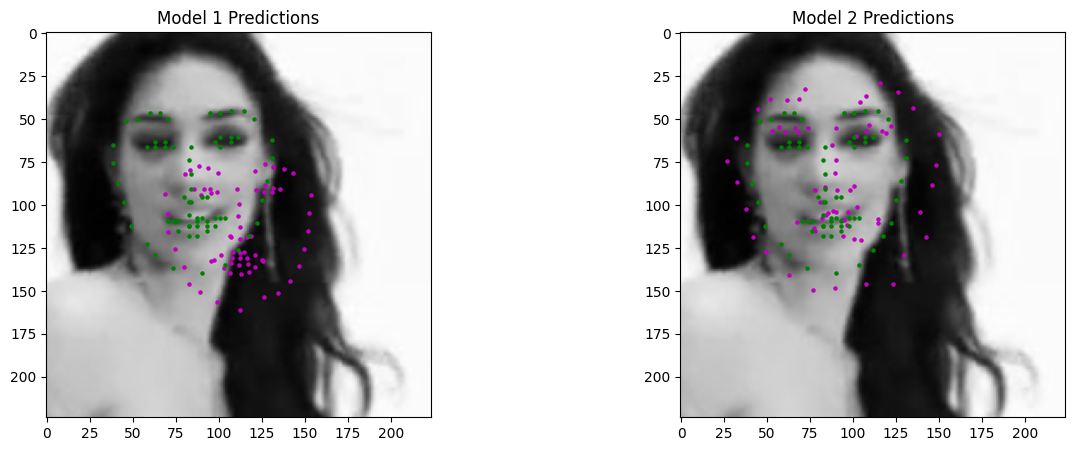

Model 1 - Overall MSE: 16590.4001, Average MSE: 21.5460
Model 2 - Overall MSE: 6675.4637, Average MSE: 8.6694


In [ ]:
# Compare net1 and net2
analyze_models(net_lr001_conv4x4_mse.to(device), net_lr0001_conv4x4_mse.to(device), test_loader)


RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

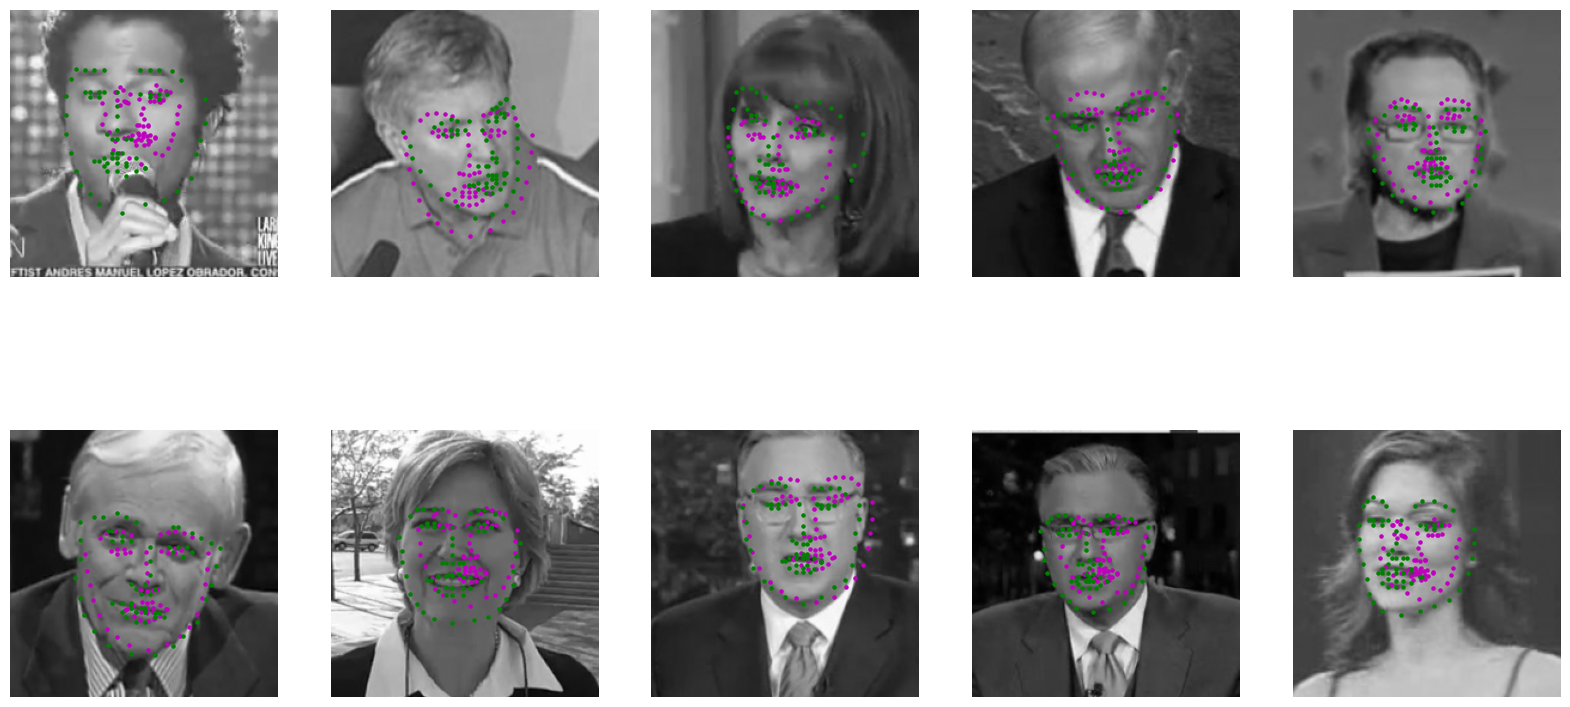

In [ ]:
# get a sample of test data again
test_images, test_outputs, gt_pts = net_sample_output(net_lr001_conv4x4_mse.cpu(), test_loader)

# visualize the test output
visualize_output(test_images, test_outputs, gt_pts)

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

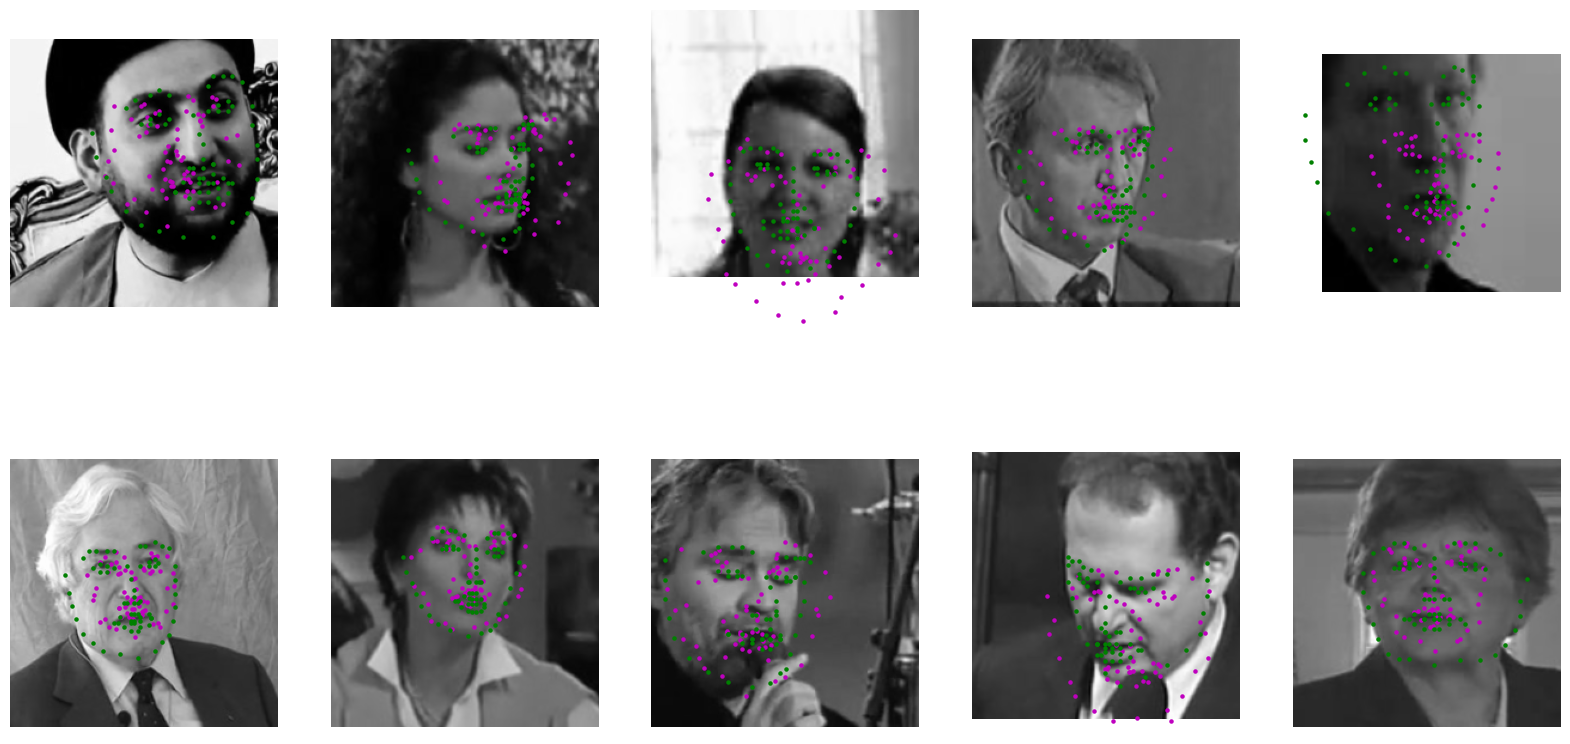

In [ ]:
# get a sample of test data again
test_images, test_outputs, gt_pts = net_sample_output(net_lr0001_conv4x4_mse.cpu(), test_loader)

# visualize the test output
visualize_output(test_images, test_outputs, gt_pts)

### Convolutional Filters: 4 vs 5 

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

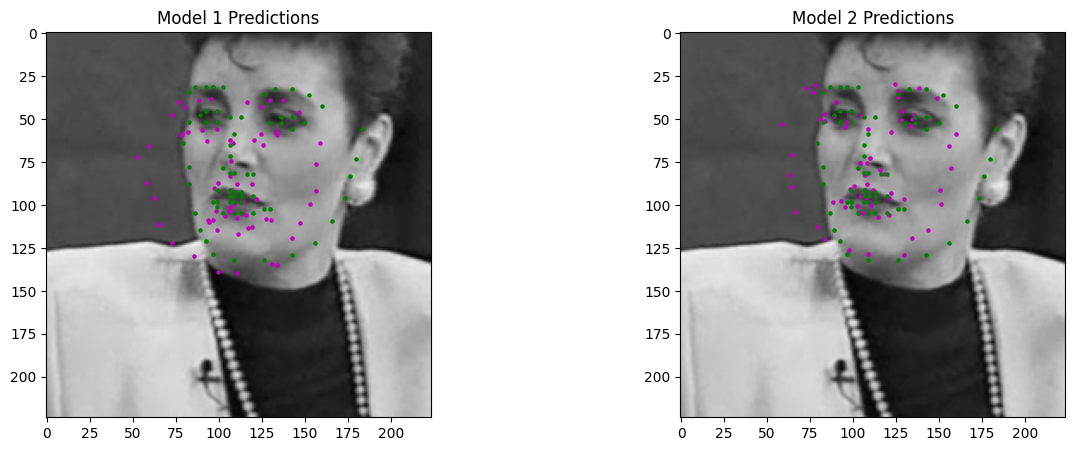

Model 1 - Overall MSE: 6959.4704, Average MSE: 9.0383
Model 2 - Overall MSE: 6706.9397, Average MSE: 8.7103


In [ ]:
analyze_models(net_lr0001_conv4x4_mse.to(device), net_lr0001_conv5x5_mse.to(device), test_loader)

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

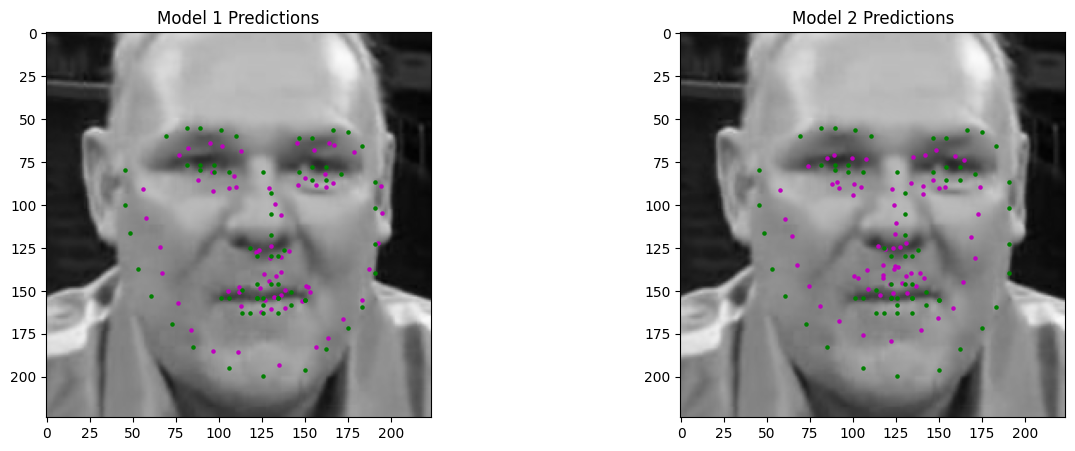

Model 1 - Overall MSE: 6538.0781, Average MSE: 8.4910
Model 2 - Overall MSE: 5973.4888, Average MSE: 7.7578


In [62]:
analyze_models(net_lr0001_conv4x4_mse.to(device), net_lr0001_conv5x5_mse.to(device), test_loader)

### MSE Loss vs SmoothL1 Loss

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

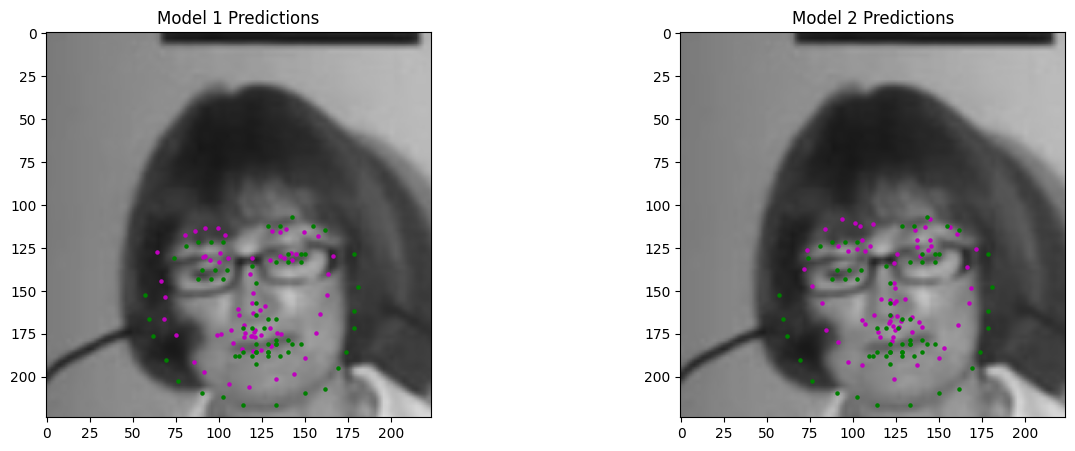

Model 1 - Overall MSE: 7673.0487, Average MSE: 9.9650
Model 2 - Overall MSE: 7679.2737, Average MSE: 9.9731


In [19]:
analyze_models(net_lr0001_conv5x5_mse.to(device), net_lr0001_conv5x5_smoothl1.to(device), test_loader)

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

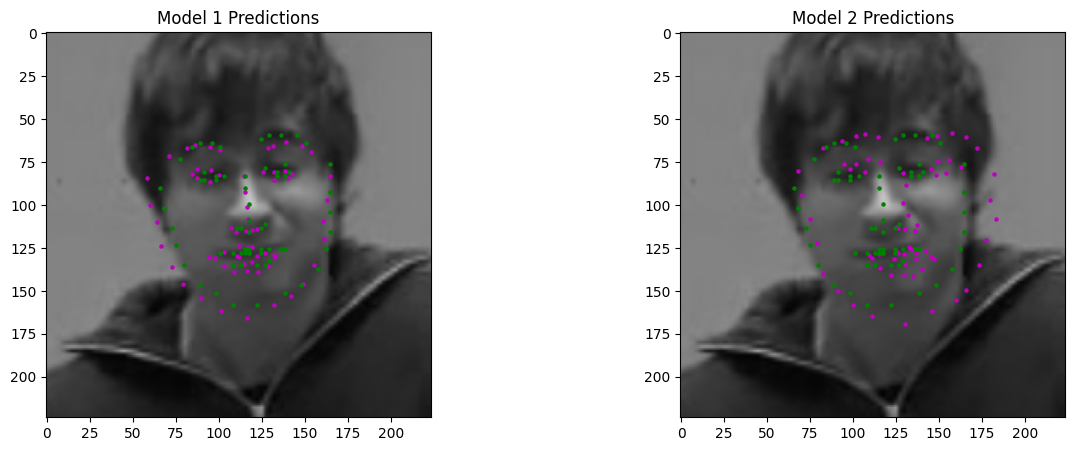

Model 1 - Overall MSE: 5531.6426, Average MSE: 7.1840
Model 2 - Overall MSE: 5204.8328, Average MSE: 6.7595


In [63]:
analyze_models(net_lr0001_conv5x5_mse.to(device), net_lr0001_conv5x5_smoothl1.to(device), test_loader)

## Visualize with Best Hyperparameters

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

torch.Size([16, 1, 224, 224])
torch.Size([16, 68, 2])
torch.Size([16, 68, 2])


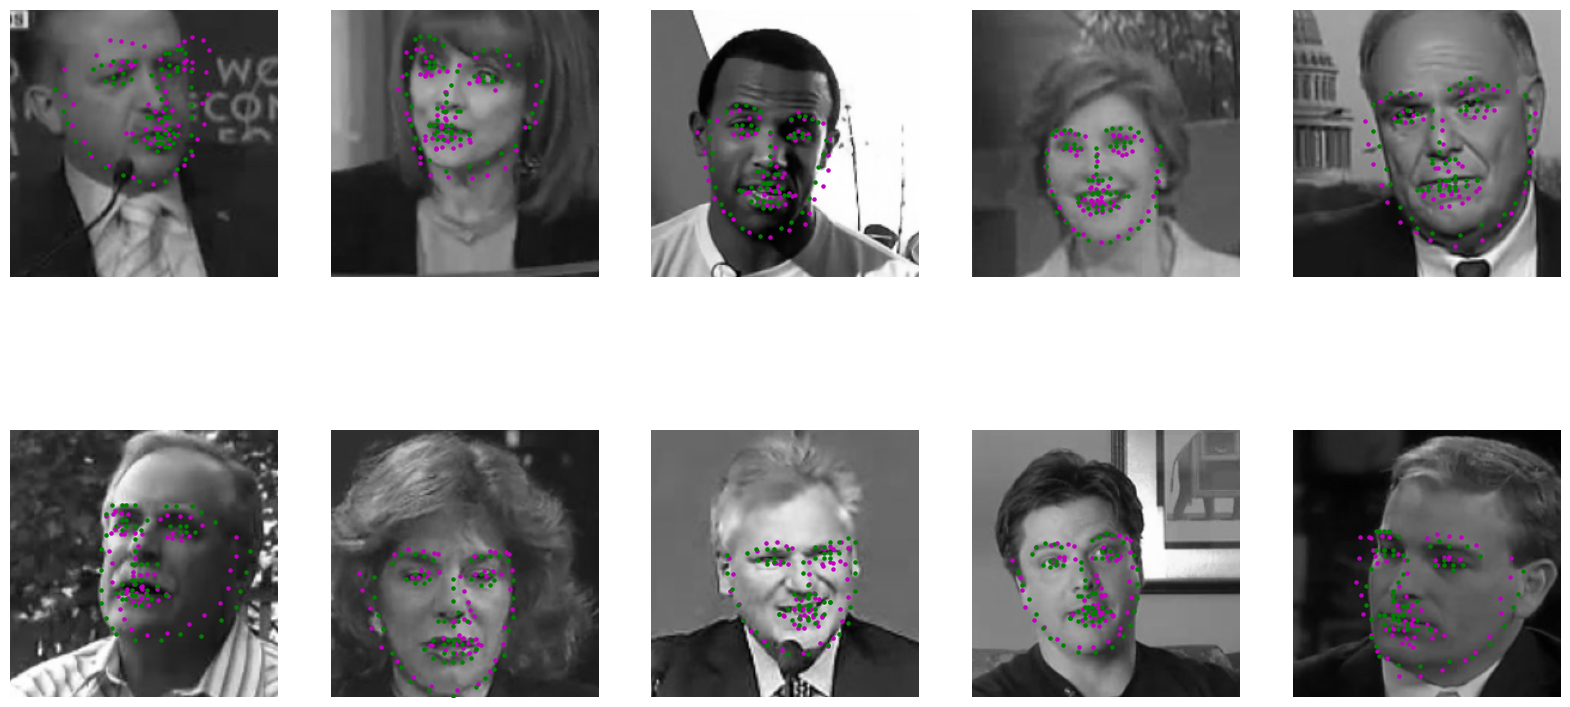

In [ ]:
# get a sample of test data again
test_images, test_outputs, gt_pts = net_sample_output(net_lr0001_conv5x5_smoothl1.cpu(), test_loader)

print(test_images.data.size())
print(test_outputs.data.size())
print(gt_pts.size())

# visualize the test output
visualize_output(test_images, test_outputs, gt_pts)

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

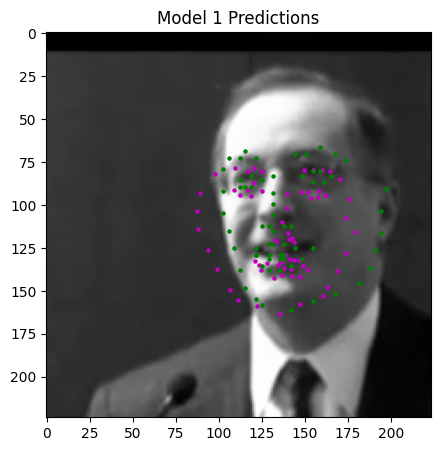

Model 1 - Overall MSE: 6867.4747, Average MSE: 8.9188


In [60]:
analyze_models(net_lr0001_conv5x5_smoothl1.to(device), None, test_loader)

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

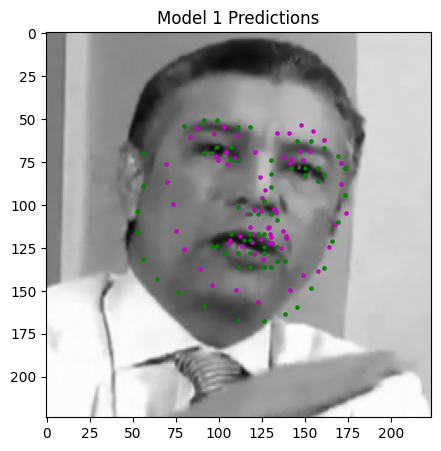

Model 1 - Overall MSE: 5626.3506, Average MSE: 7.3069


In [67]:
analyze_models(net_lr0001_conv5x5_smoothl1.to(device), None, test_loader)

## ResNet

### Visualization

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

torch.Size([16, 1, 224, 224])
torch.Size([16, 68, 2])
torch.Size([16, 68, 2])


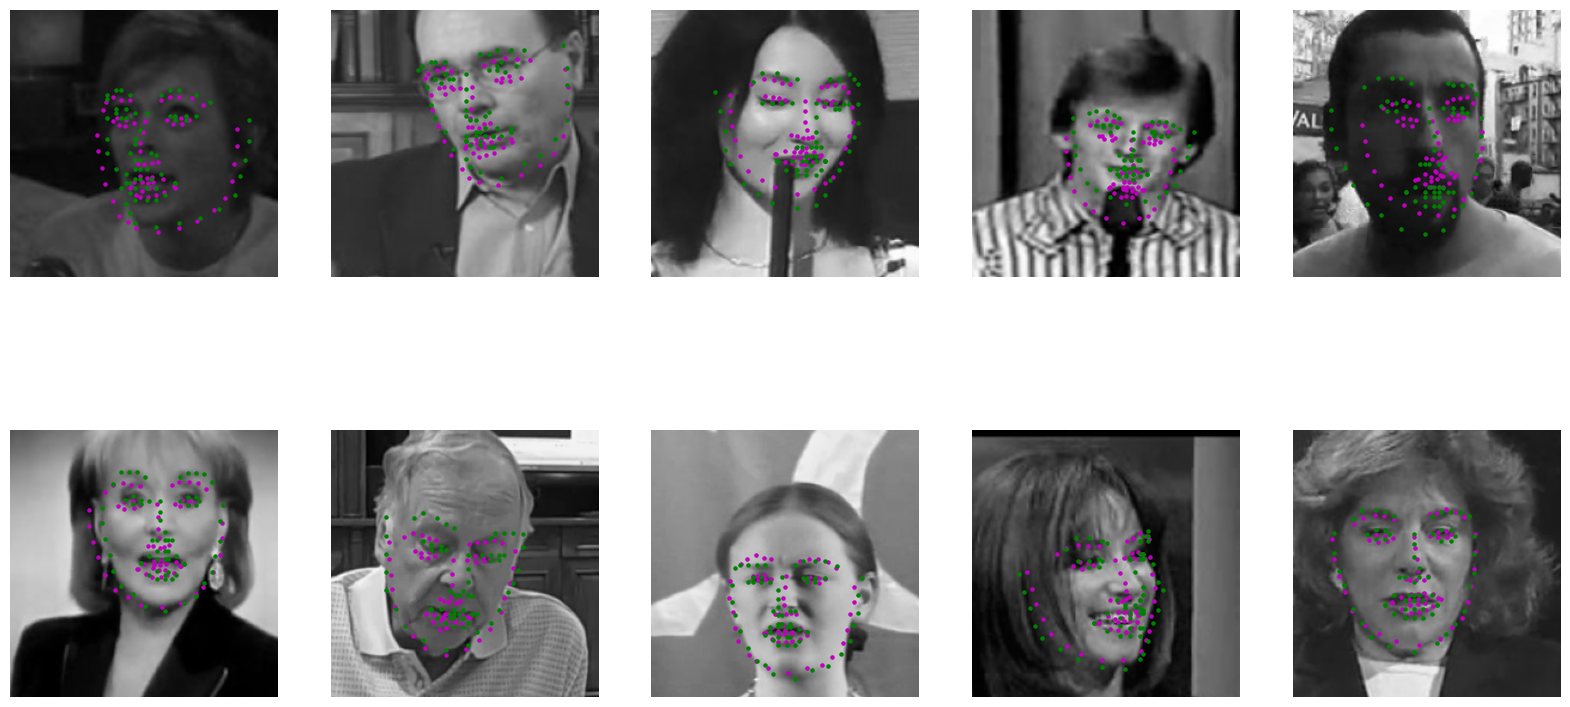

In [18]:
# get a sample of test data again
test_images, test_outputs, gt_pts = net_sample_output(resnet_lr0001_smoothl1.cpu(), test_loader)

print(test_images.data.size())
print(test_outputs.data.size())
print(gt_pts.size())

# visualize the test output
visualize_output(test_images, test_outputs, gt_pts)

### Compare ResNet with Simple CNN

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

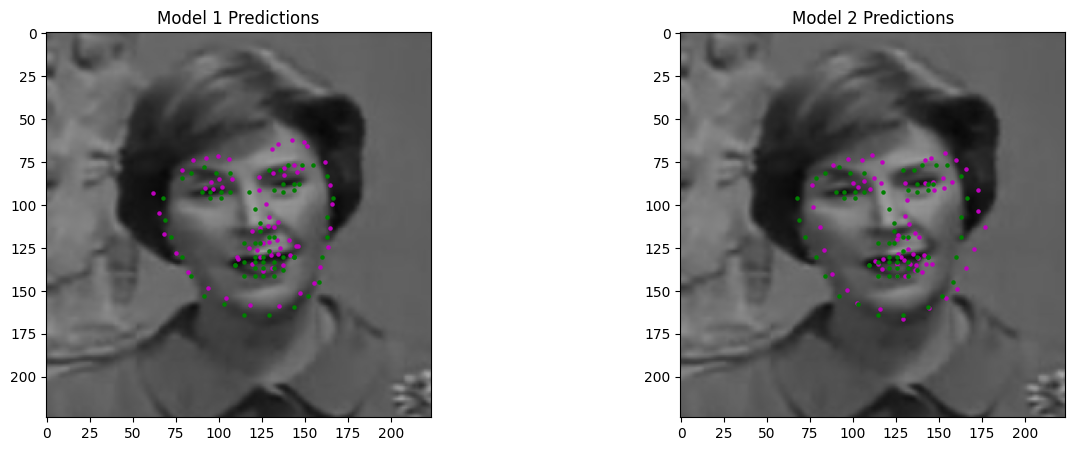

Model 1 - Overall MSE: 2200.6739, Average MSE: 2.8580
Model 2 - Overall MSE: 5386.9064, Average MSE: 6.9960


In [25]:
analyze_models(resnet_lr0001_smoothl1.to(device), net_lr0001_conv5x5_smoothl1.to(device), test_loader)

## DINO

### Visualization

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

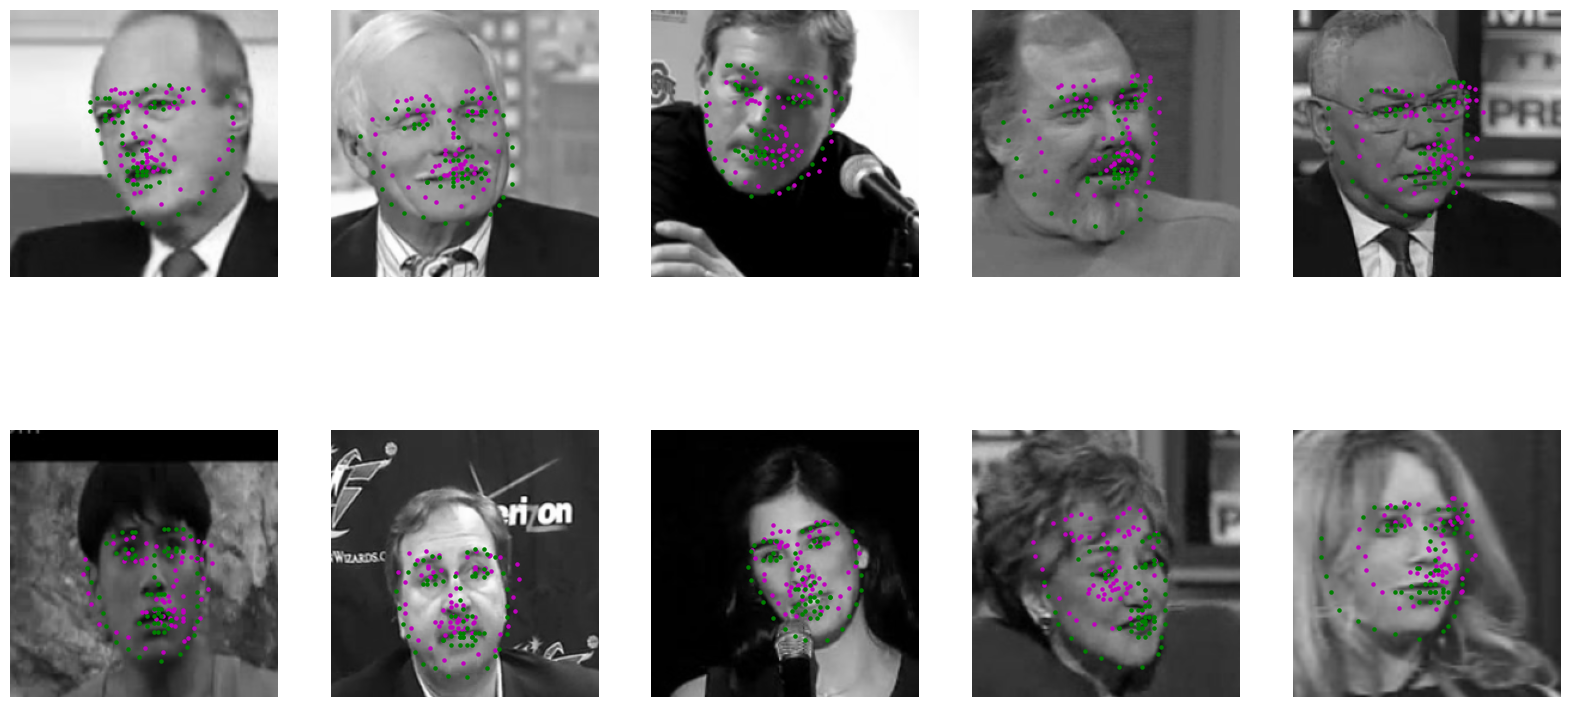

In [40]:
# get a sample of test data again
test_images, test_outputs, gt_pts = net_sample_output(dino_lr0001_smoothl1.cpu(), test_loader)
visualize_output(test_images, test_outputs, gt_pts)

### Compare DINO with ResNet

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

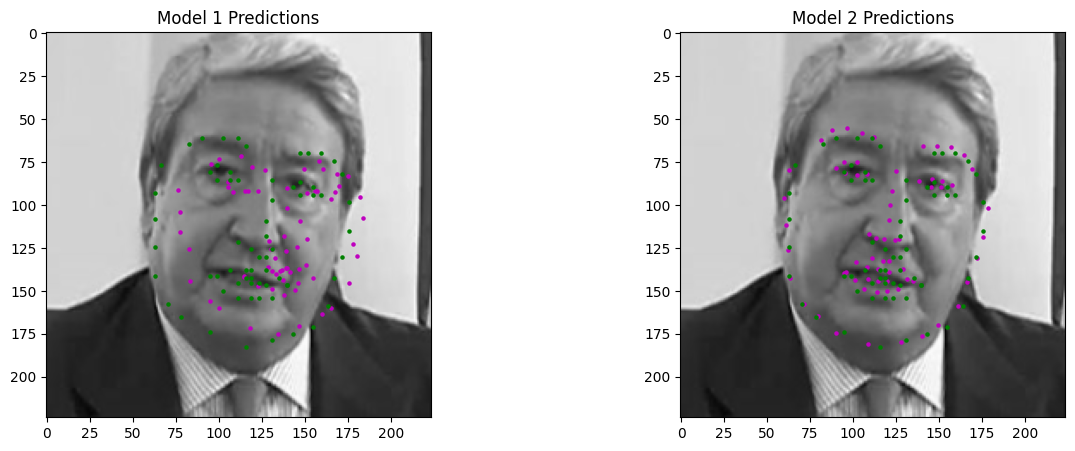

Model 1 - Overall MSE: 6626.2470, Average MSE: 8.6055
Model 2 - Overall MSE: 3234.8021, Average MSE: 4.2010


In [43]:
analyze_models(dino_lr0001_smoothl1.to(device), resnet_lr0001_smoothl1.to(device), test_loader)

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

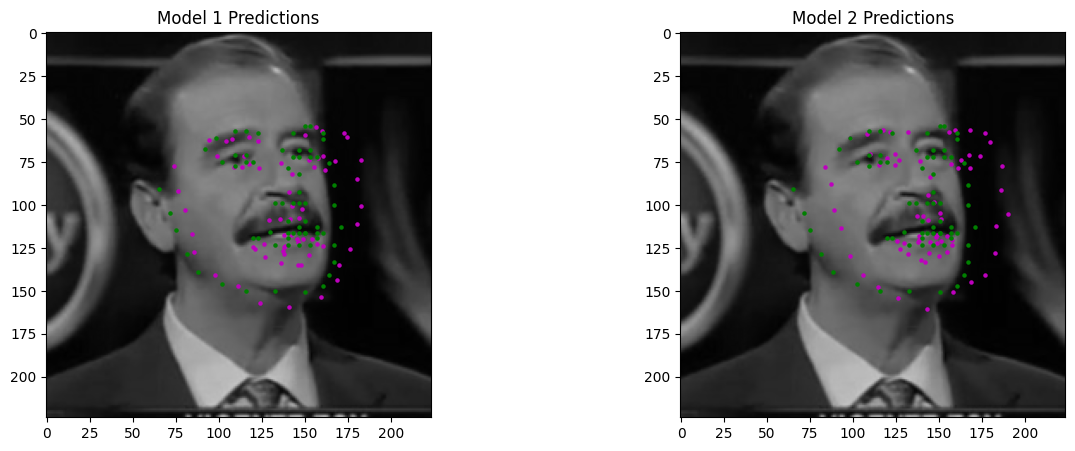

Model 1 - Overall MSE: 5981.9107, Average MSE: 7.7687
Model 2 - Overall MSE: 5730.3121, Average MSE: 7.4420


In [46]:
analyze_models(dino_lr0001_smoothl1.to(device), net_lr0001_conv5x5_smoothl1.to(device), test_loader)

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

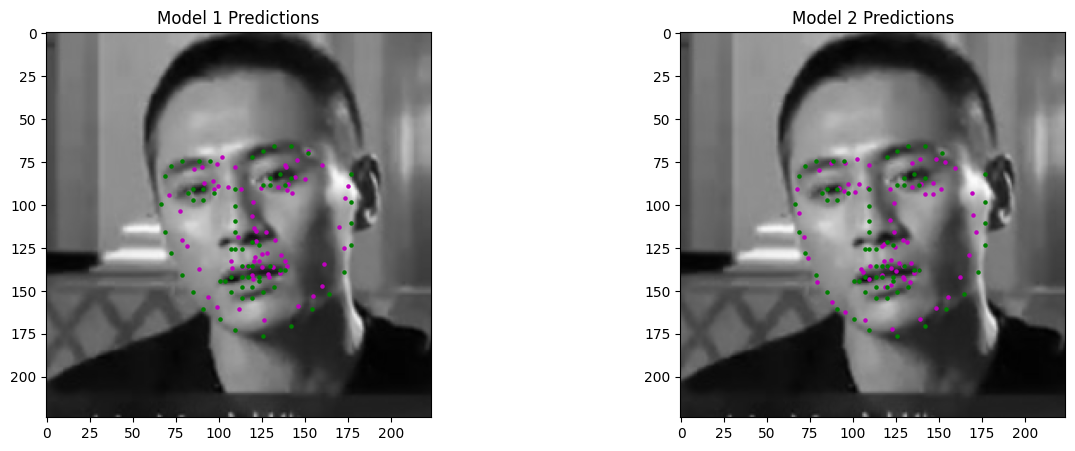

Model 1 - Overall MSE: 5504.1865, Average MSE: 7.1483
Model 2 - Overall MSE: 5107.6954, Average MSE: 6.6334


In [71]:
analyze_models(dino_lr0001_smoothl1.to(device), net_lr0001_conv5x5_smoothl1.to(device), test_loader)

# Training UNet with Heatmaps

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

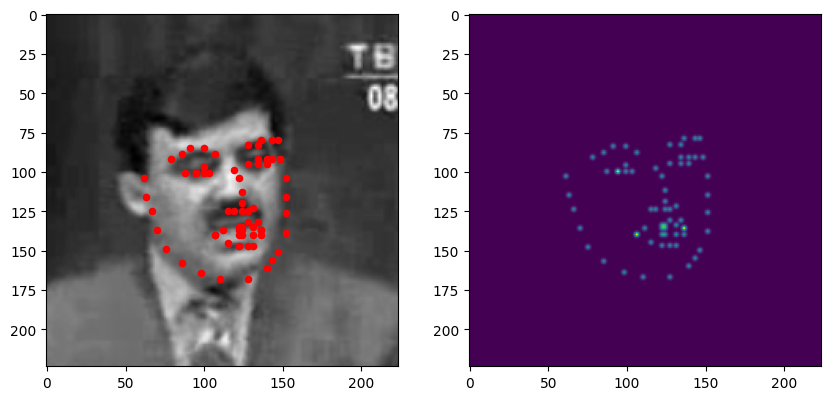

In [76]:
# importing the required libraries
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, utils
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torch.optim import lr_scheduler
import torch.optim as optim
from tqdm import tqdm


# the transforms we defined in Notebook 1 are in the helper file `custom_transforms.py`
from custom_transforms import (
    Rescale,
    RandomCrop,
    NormalizeOriginal,
    ToTensor,
)

# the dataset we created in Notebook 1
from facial_keypoints_dataset import FacialKeypointsHeatmapDataset



# defining the data_transform using transforms.Compose([all tx's, . , .])
# order matters! i.e. rescaling should come before a smaller crop
data_transform = transforms.Compose(
    [Rescale(250), RandomCrop(224), NormalizeOriginal(), ToTensor()]
)

training_keypoints_csv_path = os.path.join("data", "training_frames_keypoints.csv")
training_data_dir = os.path.join("data", "training")
test_keypoints_csv_path = os.path.join("data", "test_frames_keypoints.csv")
test_data_dir = os.path.join("data", "test")


# create the transformed dataset
transformed_dataset = FacialKeypointsHeatmapDataset(
    csv_file=training_keypoints_csv_path,
    root_dir=training_data_dir,
    transform=data_transform,
    output_size=224
)
# load training data in batches
batch_size = 8
train_loader = DataLoader(
    transformed_dataset, batch_size=batch_size, shuffle=True, num_workers=4
)

# creating the test dataset
test_dataset = FacialKeypointsHeatmapDataset(
    csv_file=test_keypoints_csv_path,
    root_dir=test_data_dir,
    transform=data_transform,
    output_size=224
)
# loading test data in batches
batch_size = 8
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True, num_workers=4
)

for i, data in enumerate(test_loader):
    sample = data
    image = sample['image'][0]
    keypoints = sample['keypoints'][0]
    # plot the image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image.numpy().transpose(1, 2, 0), cmap='gray')
    plt.scatter(keypoints[:, 0]*50+100, keypoints[:, 1]*50+100, c='r', s=20)
    # show the heatmaps
    plt.subplot(1, 2, 2)
    heatmaps = sample['heatmaps'][0].sum(dim=0, keepdim=True)
    plt.imshow(heatmaps.numpy().transpose(1, 2, 0))
    plt.show()
    break


In [ ]:
# save loss curves
def save_loss(losses, filename):
    plt.plot(losses)
    plt.title("Loss vs. Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.savefig(filename)
    plt.close()


## Model

In [10]:
class Conv(nn.Module):
   def __init__(self, in_channels: int, out_channels: int):
       super().__init__()
       self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1)
       self.bn = nn.BatchNorm2d(out_channels)
       self.gelu = nn.GELU()

   def forward(self, x: torch.Tensor) -> torch.Tensor:
       return self.gelu(self.bn(self.conv(x)))

class DownConv(nn.Module):
   def __init__(self, in_channels: int, out_channels: int):
       super().__init__()
       self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1)
       self.bn = nn.BatchNorm2d(out_channels)
       self.gelu = nn.GELU()

   def forward(self, x: torch.Tensor) -> torch.Tensor:
       return self.gelu(self.bn(self.conv(x)))

class UpConv(nn.Module):
   def __init__(self, in_channels: int, out_channels: int):
       super().__init__()
       self.conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1)
       self.bn = nn.BatchNorm2d(out_channels)
       self.gelu = nn.GELU()

   def forward(self, x: torch.Tensor) -> torch.Tensor:
       return self.gelu(self.bn(self.conv(x)))

class Flatten(nn.Module):
   def __init__(self):
       super().__init__()
       self.pool = nn.AvgPool2d(7)
       self.gelu = nn.GELU()

   def forward(self, x: torch.Tensor) -> torch.Tensor:
       return self.gelu(self.pool(x))

class Unflatten(nn.Module):
   def __init__(self, in_channels: int):
       super().__init__()
       self.conv = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7, stride=7, padding=0)
       self.bn = nn.BatchNorm2d(in_channels)
       self.gelu = nn.GELU()

   def forward(self, x: torch.Tensor) -> torch.Tensor:
       return self.gelu(self.bn(self.conv(x)))

class ConvBlock(nn.Module):
   def __init__(self, in_channels: int, out_channels: int):
       super().__init__()
       self.conv1 = Conv(in_channels, out_channels)
       self.conv2 = Conv(out_channels, out_channels)

   def forward(self, x: torch.Tensor) -> torch.Tensor:
       return self.conv2(self.conv1(x))

class DownBlock(nn.Module):
   def __init__(self, in_channels: int, out_channels: int):
       super().__init__()
       self.down = DownConv(out_channels, out_channels)
       self.conv_block = ConvBlock(in_channels, out_channels)

   def forward(self, x: torch.Tensor) -> torch.Tensor:
       return self.down(self.conv_block(x))

class UpBlock(nn.Module):
   def __init__(self, in_channels: int, out_channels: int):
       super().__init__()
       self.up = UpConv(out_channels, out_channels)
       self.conv_block = ConvBlock(in_channels, out_channels)

   def forward(self, x: torch.Tensor) -> torch.Tensor:
       return self.up(self.conv_block(x))

In [11]:

class HeatmapUNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,         # grayscale input images
        num_hiddens: int = 128,        # base number of channels
        num_keypoints: int = 68       # number of facial keypoints
    ):
        super().__init__()
        self.in_channels = in_channels
        self.num_hiddens = num_hiddens
        self.num_keypoints = num_keypoints

        # Encoder path (downsampling)
        self.conv_initial = ConvBlock(in_channels, num_hiddens)  # 224x224 -> 224x224
        self.down1 = DownBlock(num_hiddens, num_hiddens*2)       # 224x224 -> 112x112
        self.down2 = DownBlock(num_hiddens*2, num_hiddens*4)     # 112x112 -> 56x56
        self.down3 = DownBlock(num_hiddens*4, num_hiddens*8)     # 56x56 -> 28x28
        self.down4 = DownBlock(num_hiddens*8, num_hiddens*16)    # 28x28 -> 14x14

        # Decoder path (upsampling)
        self.up1 = UpBlock(num_hiddens*16, num_hiddens*8)        # 14x14 -> 28x28
        self.up2 = UpBlock(num_hiddens*8*2, num_hiddens*4)       # 28x28 -> 56x56
        self.up3 = UpBlock(num_hiddens*4*2, num_hiddens*2)       # 56x56 -> 112x112
        self.up4 = UpBlock(num_hiddens*2*2, num_hiddens)         # 112x112 -> 224x224
        self.convblock = ConvBlock(num_hiddens*2, num_hiddens)  # 224x224 -> 224x224
        self.final_conv = nn.Conv2d(num_hiddens, num_keypoints, kernel_size=3, stride=1, padding=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder path with stored features for skip connections
        x1 = self.conv_initial(x)        # 224x224
        x2 = self.down1(x1)              # 112x112
        x3 = self.down2(x2)              # 56x56
        x4 = self.down3(x3)              # 28x28
        x5 = self.down4(x4)              # 14x14 (bottleneck)

        # Decoder path with skip connections
        x = self.up1(x5)                 # 28x28
        x = self.up2(torch.cat([x4, x], dim=1))  # 56x56
        x = self.up3(torch.cat([x3, x], dim=1))  # 112x112
        x = self.up4(torch.cat([x2, x], dim=1))  # 224x224

        # Output layer
        x = self.convblock(torch.cat([x1, x], dim=1))
        heatmaps = self.final_conv(x)

        x = self.convblock(torch.cat([x1, x], dim=1))
        logits = self.final_conv(x)  # Shape: [batch_size, 68, 224, 224]

        # Apply softmax over the spatial dimensions (H,W) as mentioned in the description
        # First reshape to [batch_size, 68, 224*224]
        batch_size, channels, height, width = logits.size()
        logits_flat = logits.reshape(batch_size, channels, -1)
        # Apply softmax over the flattened spatial dimension
        heatmap_flat = F.softmax(logits_flat, dim=2)
        # Reshape back to [batch_size, 68, 224, 224]
        heatmaps = heatmap_flat.reshape(batch_size, channels, height, width)
        return heatmaps

## Train

In [ ]:
net = HeatmapUNet()
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(net.parameters(), lr=5e-3)
losses = []
def train_net(n_epochs):
  net.train()
  net.to(device)
  losses = []
  for epoch in tqdm(range(n_epochs)):
    running_loss = 0.0
    for data in tqdm(train_loader, desc="epoch {}".format(epoch), disable=True):
      optimizer.zero_grad()
      images, heatmap = data['image'].to(device), data['heatmaps'].to(device)
      output = net(images)
      loss = criterion(output, heatmap)
      loss.backward()
      optimizer.step()
      del images, heatmap, output
      torch.cuda.empty_cache()

      running_loss += loss.item()
    # checkpoint model
    if epoch % 5 == 0:
      torch.save(net.state_dict, f"{save_path}epoch_{epoch}.pth")
    losses.append(running_loss / len(train_loader))
  return losses

In [ ]:
heatmap_losses = train_net(25)

100%|██████████| 25/25 [57:09<00:00, 137.19s/it]


In [ ]:
torch.save(net.state_dict, f"{save_path}epoch_final.pth")

In [ ]:
torch.save(net.state_dict, "model.pth")

In [ ]:
# save loss curves
def save_loss(losses, filename):
    plt.plot(losses)
    plt.title("Loss vs. Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.savefig(filename)
    plt.close()
save_loss(heatmap_losses, "losses_heatmap.png")

In [78]:
heatmap_unet = HeatmapUNet()
heatmap_unet.load_state_dict(torch.load("models/heatmap_unet.pth", weights_only=False, map_location=device)())

<All keys matched successfully>

## Visualize

In [19]:
# TODO: visualize your predictions

def show_all_keypoints(image, predicted_key_pts, gt_pts=None):
    """
    Show image with predicted keypoints and optionally ground truth keypoints
    """
    # Convert grayscale to RGB if needed
    if len(image.shape) == 2:
        image = np.stack([image]*3, axis=2)

    plt.imshow(image*255, cmap='gray')
    plt.scatter(predicted_key_pts[:, 0], predicted_key_pts[:, 1], s=20, marker='.', c='m')

    if gt_pts is not None:
        # plt.imshow(image*255, cmap='gray')
        plt.scatter(gt_pts[:, 0], gt_pts[:, 1], s=20, marker='.', c='g')


# test the model on a batch of test images
def net_sample_output(model, test_loader):

    # iterate through the test dataset
    for i, sample in enumerate(test_loader):

        # getting sample data: images and ground truth keypoints
        images = sample["image"]
        key_pts = sample["keypoints"]

        # converting images to FloatTensors
        images = images.type(torch.FloatTensor)

        # forwarding pass to get net output
        output_heatmap = model(images.to(device))
        # extract keypoint coordinates from the predicted heatmaps using argmax
        array = output_heatmap.detach().cpu().numpy()
        batch_size, num_keypoints = array.shape[0], array.shape[1]
        flattened = array.reshape(batch_size, num_keypoints, -1) # index k = y * 224 + x
        flat_indices = np.argmax(flattened, axis=2)
        y_coords = flat_indices // 224
        x_coords = flat_indices % 224
        output_pts = np.stack([x_coords, y_coords], axis=2)

        # reshaping to batch_size x 68 x 2 pts # (136*1) => (68*2)
        # output_pts = output_pts.view(output_pts.size()[0], 68, -1)

        # break after first image is tested
        if i == 0:
            return (
                images,
                # output_pts,
                output_pts,
                key_pts,
            )  # images, predicted key points, real keypoints

# visualize the output
def visualize_output(test_images, test_outputs, gt_pts=None, batch_size=5):
    plt.figure(figsize=(20, 10))
    for i in range(batch_size):
        ax = plt.subplot(batch_size // 5, 5, i + 1)

        # un-transform the image data
        image = test_images[i].data  # get the image from its Variable wrapper
        image = image.numpy()  # convert to numpy array from a Tensor
        image = np.transpose(
            image, (1, 2, 0)
        )  # transpose to go from torch to numpy image

        # un-transform the predicted key_pts data
        predicted_key_pts = test_outputs[i]

        # plot ground truth points for comparison, if they exist
        ground_truth_pts = gt_pts[i]
        ground_truth_pts = ground_truth_pts * 50.0 + 100

        # call show_all_keypoints
        show_all_keypoints(np.squeeze(image), predicted_key_pts, ground_truth_pts)

        plt.axis("off")

    plt.show()

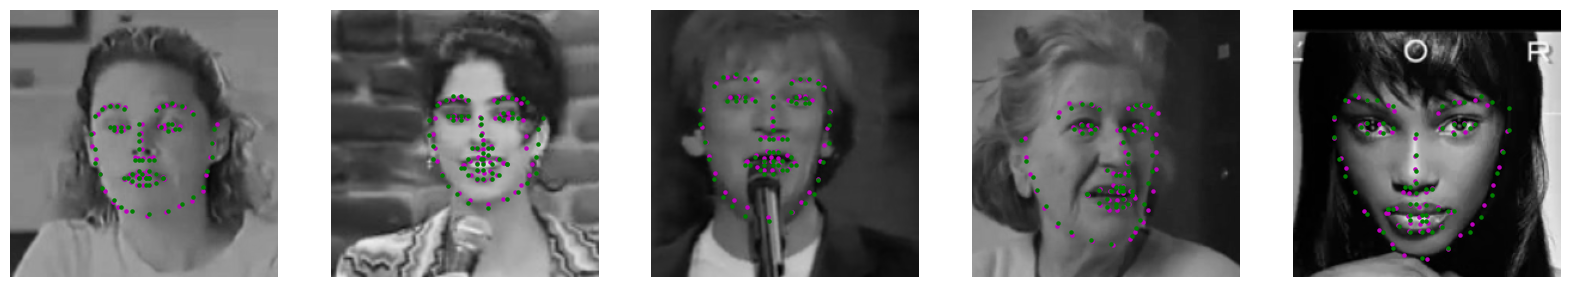

In [ ]:
test_images, test_outputs, gt_pts = net_sample_output(heatmap_unet.to(device), test_loader)
visualize_output(test_images, test_outputs, gt_pts)

RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/Users/brayton/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Visual Studio Projects/Academics/Computer Vision/hw3/facial_keypoints_dataset.py:6: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.6)
  from scipy.ndimage import gaussian_filter
RuntimeError: module was compiled against NumPy C-API version 0x10 (NumPy 1.23) but the running NumPy has C-API version 0xe. Check the section C-API incompatibility at the Troubleshooting ImportError section at https://numpy.org/devdocs/user/troubleshooting-importerror.html#c-api-incompatibility for indications on how to solve this problem.
/User

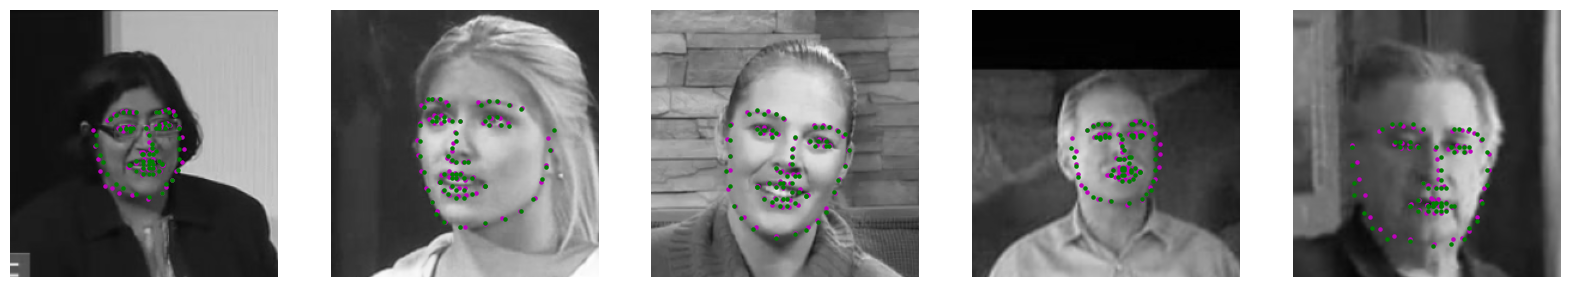

In [73]:
test_images, test_outputs, gt_pts = net_sample_output(heatmap_unet.to(device), test_loader)
visualize_output(test_images, test_outputs, gt_pts)

## Visualize heatmap with ground truth


In [ ]:
def visualize_heatmaps_with_ground_truth(model, test_loader, batch_size=5):
    """
    Visualize the predicted heatmaps and ground truth heatmaps for a batch of test images.
    """
    with torch.no_grad():
        for i, sample in enumerate(test_loader):
            images = sample["image"].to(device)
            gt_heatmaps = sample["heatmaps"].to(device)

            # Get the predicted heatmaps
            pred_heatmaps = model(images)

            # Visualize the heatmaps
            plt.figure(figsize=(15, 10))
            for j in range(batch_size):
                # Original image
                ax = plt.subplot(batch_size, 3, j * 3 + 1)
                image = images[j].cpu().numpy().transpose(1, 2, 0)
                plt.imshow(image, cmap="gray")
                plt.title("Original Image")
                plt.axis("off")

                # Ground truth heatmap
                ax = plt.subplot(batch_size, 3, j * 3 + 2)
                gt_heatmap = gt_heatmaps[j].cpu().numpy().sum(axis=0)
                plt.imshow(gt_heatmap, cmap="hot")
                plt.title("Ground Truth Heatmap")
                plt.axis("off")

                # Predicted heatmap
                ax = plt.subplot(batch_size, 3, j * 3 + 3)
                pred_heatmap = pred_heatmaps[j].cpu().numpy().sum(axis=0)
                plt.imshow(pred_heatmap, cmap="hot")
                plt.title("Predicted Heatmap")
                plt.axis("off")

            plt.show()
            break  # Visualize only the first batch


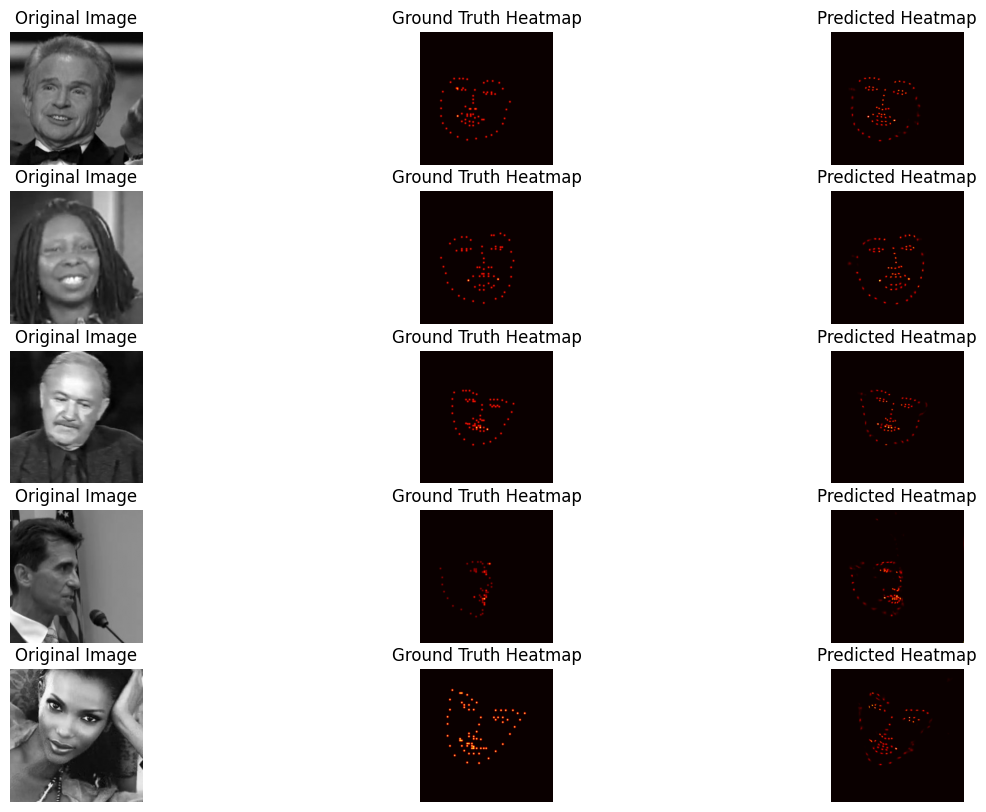

In [ ]:

# Call the function to visualize
visualize_heatmaps_with_ground_truth(heatmap_unet, test_loader)

## Compare

In [ ]:
def analyze_models_with_heatmap(heatmap_model, test_loader=None):
    """
    Compare two models by calculating overall and average MSE and displaying one example of predictions.
    If model2 is None, only analyze model1.
    """
    mse_heatmap = 0
    total_samples = 0

    with torch.no_grad():
        for i, sample in enumerate(test_loader):
            images = sample["image"].type(torch.FloatTensor).to(device)
            key_pts = sample["keypoints"].type(torch.FloatTensor).to(device)
            ground_truth_pts = key_pts[0].cpu().numpy() * 50.0 + 100

            # Predictions for heatmap model
            output_heatmap = heatmap_model(images)
            # Extract keypoint coordinates from heatmaps
            array = output_heatmap.cpu().numpy()
            batch_size, num_keypoints = array.shape[0], array.shape[1]
            flattened = array.reshape(batch_size, num_keypoints, -1)
            flat_indices = np.argmax(flattened, axis=2)
            y_coords = flat_indices // 224
            x_coords = flat_indices % 224

            # Convert to tensor for MSE calculation
            heatmap_pts = torch.zeros(batch_size, 68, 2, device=device)
            heatmap_pts[:, :, 0] = torch.tensor(x_coords, device=device)
            heatmap_pts[:, :, 1] = torch.tensor(y_coords, device=device)

            # Normalize to match ground truth scale
            heatmap_pts = (heatmap_pts - 100) / 50.0

            # Calculate MSE for heatmap model
            mse_heatmap += torch.sum((heatmap_pts - key_pts) ** 2).item()
            total_samples += images.size(0)

            # Display one example for model1 and model2
            if i == 0:
                # Heatmap model example
                plt.plot()
                # For visualization, we need the unnormalized coordinates
                heatmap_pred_pts = np.stack([x_coords[0], y_coords[0]], axis=1)
                show_all_keypoints(
                    np.squeeze(images[0].cpu().numpy().transpose(1, 2, 0)),
                    heatmap_pred_pts,
                    ground_truth_pts,
                )
                plt.title("Heatmap Model Predictions")
                plt.show()

    # Calculate overall and average MSE
    overall_mse_heatmap = mse_heatmap
    avg_mse_heatmap = mse_heatmap / total_samples
    print(f"Heatmap Model - Overall MSE: {overall_mse_heatmap:.4f}, Average MSE: {avg_mse_heatmap:.4f}")

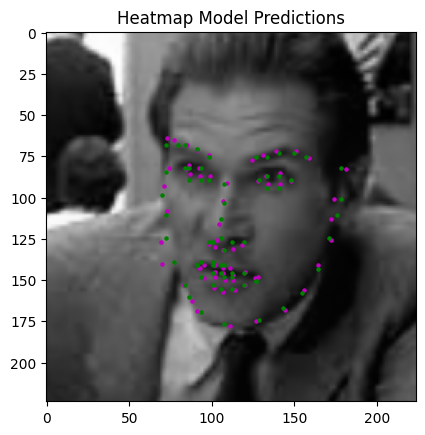

Heatmap Model - Overall MSE: 1814.4781, Average MSE: 2.3565


In [ ]:
analyze_models_with_heatmap(heatmap_unet.to(device), test_loader)

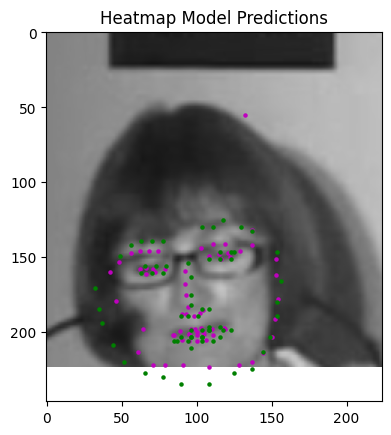

Heatmap Model - Overall MSE: 1669.5505, Average MSE: 2.1682


In [ ]:
analyze_models_with_heatmap(net.to(device), test_loader)
